In [78]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Latex

In [79]:
kk = 10000

def Eanomaly(e, phi):
    return (e+np.cos(phi))/(1+e*np.cos(phi))

def orbsystem(t, X, q, M, R = 100, m3 = 1):
    a, e, phi = X
    r = a*(1-e**2)/(1+e*np.cos(phi))
    F = np.sqrt((m3+M)/R**3)*t
    curlyR = 0 #-(m3*r/R**3)*(1-3*np.cos(phi-F)**2)
    curlyS = 0 #-3*(m3*r/R**3)*np.sin(phi - F)
    E = (e+np.cos(phi))/(1+e*np.cos(phi))
    dadt =  -(64/5)*(M**3 / a**3)*(q/(1+q)**2)*((1+(73/24)*e**2 + (37/96)*e**4)/(1-e**2)**(7/2))
    #+ (2*a**(3/2)/(M*np.sqrt(1-e**2)))*(e*np.sin(phi)*curlyR + (1+e*np.cos(phi))*curlyS)
    dedt =  -(304/15)*(M**3 / a**4)*(q/(1+q)**2)*(e*(1+((121/304)*e**2))/(1-e**2)**(5/2))  + np.sqrt(a*(1-e**2)/M)*(np.sin(phi)*curlyR + (np.cos(phi)+E)*curlyS)
    dphidt = (M**(1/2)/a**(3/2))*(((1+e*np.cos(phi))**2) /(1-e**2)**(3/2))
    
    return [dadt, dedt, dphidt]

arg = (1, 1)
t_span = (0, kk)
t_eval = np.linspace(0, kk, kk*10)
y0 = [15, 0.2, 0]
sols = sp.integrate.solve_ivp(fun=orbsystem, t_span=t_span, y0=y0, args=arg, t_eval=t_eval, method='RK45', rtol=1e-10,
    atol=1e-12)


t0 = sols.t
kk = np.max(t0)
timef = sols.t - kk
a_ref, e_newt, phi_ref = sols.y   

Text(0, 0.5, '$e$')

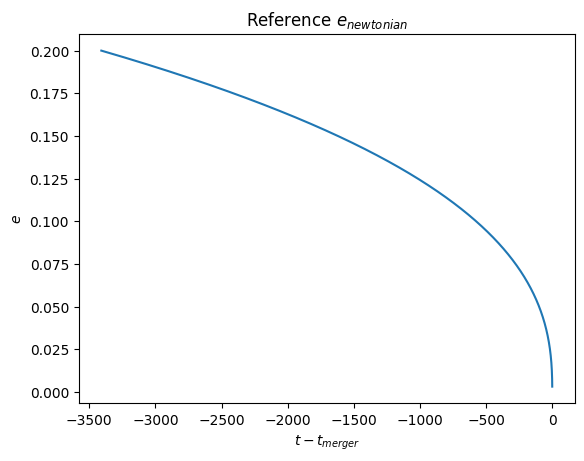

In [80]:
plt.plot(timef, e_newt)
plt.title(r'Reference $e_{newtonian}$')
plt.xlabel(r'$t-t_{merger}$')
plt.ylabel(r'$e$')

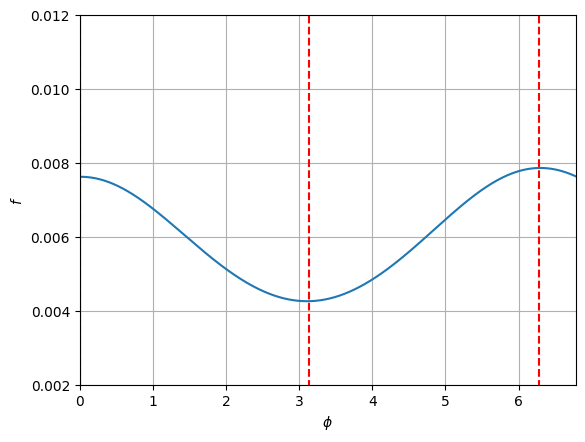

In [81]:
d = q = M = 1
dt = t0[1]-t0[0]
def hplus(a, e, phi, d, q, M):
    return -((2*np.sqrt(np.pi/5)*M**2)/(d*a*(1-e**2)))*(q/(1+q)**2)*(4*np.cos(2*phi)+e*(5*np.cos(phi)+np.cos(3*phi))+2*e**2)

def hcross(a, e, phi, d, q, M):
    return ((4*np.sqrt(np.pi/5)*M**2)/(d*a*(1-e**2)))*(q/(1+q)**2)*np.sin(phi)*(4*np.cos(phi)+e*(3+np.cos(2*phi)))

def theta(a, e, phi, d, q, M):
    dthe =  np.arctan2(-hcross(a, e, phi, d, q, M), hplus(a, e, phi, d, q, M))
    return np.unwrap(dthe)

#time to construct Fourier phase, and somehow get fplus and fminus. Not clear about this step just yet but I will try
theta1 = theta(a_ref, e_newt, phi_ref, d, q, M)
dtheta_dt = sp.signal.savgol_filter(theta1, window_length=15, polyorder=3, deriv=1, delta=dt)
# #dtheta = np.gradient(theta1, dt)
# t_sub = np.linspace(0, 3400, 1000)
# theta_sub = np.interp(t_sub, t0, theta1)

# cs = sp.interpolate.CubicSpline(t_sub, theta_sub)
# dtheta_dt = cs(t0, nu=1)  # Get analytical derivative of spline

fvalues = dtheta_dt / (2 * np.pi)
dfvalues = sp.signal.savgol_filter(fvalues, window_length=15, polyorder=3, deriv=1, delta=dt)
zero_crossings = np.where(dfvalues[1:] * dfvalues[:-1] < 0)[0]
verticalx = np.ones(100)
verticaly = np.linspace(0, 1, 100)
plt.plot(phi_ref, fvalues)
for i in range(3):
    plt.plot(i*np.pi*verticalx, verticaly, 'r--')
plt.xlim(0, 2*np.pi+0.5)
plt.ylim(0.002, 0.012)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$f$')
plt.grid(True)

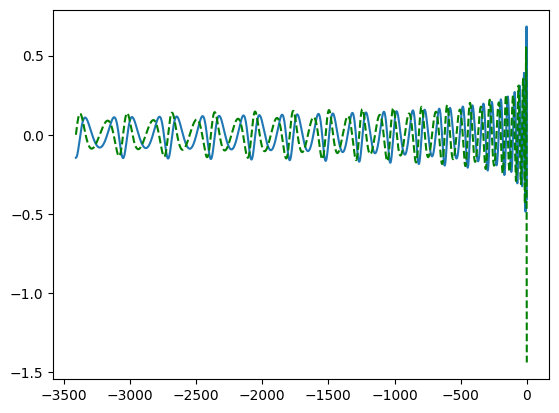

In [82]:
plt.plot(timef, hplus(a_ref, e_newt, phi_ref, d, q, M))
plt.plot(timef, hcross(a_ref, e_newt, phi_ref, d, q, M), 'g--')

In [83]:
twoindex = np.max(np.where(phi_ref < 2*np.pi))
fplus = np.max(fvalues[:twoindex])
fminus = np.min(fvalues[:twoindex])

def e_cmaker(fplus, fminus):
    iksi = (abs(fplus - fminus))/(fplus + fminus)
    psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
    e_c = np.cos(psi) - np.sqrt(3)*np.sin(psi)
    return e_c


e_c = e_cmaker(fplus, fminus)
e_c

np.float64(0.20092610099435215)

In [84]:
zero_crossings2 = np.roll(zero_crossings, shift=1)
zero_crossings3 = np.average(np.array([zero_crossings, zero_crossings2]), axis=0).astype(int)

e_c_array = e_cmaker(fvalues[zero_crossings], fvalues[zero_crossings2])
e_c_array

array([0.28566266, 0.19114248, 0.20093915, 0.1823197 , 0.19296572,
       0.17321026, 0.18484365, 0.16377494, 0.17656918, 0.15396373,
       0.16814213, 0.14371346, 0.15956732, 0.13293983, 0.15086112,
       0.12152648, 0.14206084, 0.10931173, 0.13324954, 0.09605452,
       0.12459736, 0.0813728 , 0.1164973 , 0.06463275, 0.10993857,
       0.04470165, 0.1080209 , 0.0197404 ])

Text(0, 0.5, '$e$')

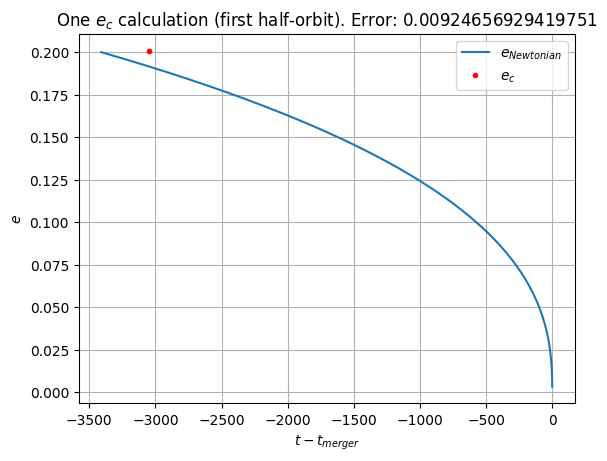

In [85]:

err = abs(e_c - e_newt[twoindex])
plt.plot(timef, e_newt, label=r"$e_{Newtonian}$")
plt.plot(timef[twoindex], e_c, 'r.', label=r"$e_c$")
#plt.plot(timef[fourindex], e_c2, 'r.')
plt.title(fr"One $e_c$ calculation (first half-orbit). Error: {err}")
plt.legend()
plt.grid(True)
plt.xlabel(r'$t-t_{merger}$')
plt.ylabel(r'$e$')



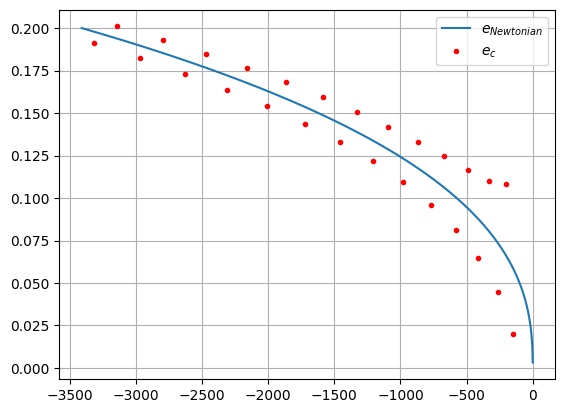

In [86]:
# Method 1: 
timec = timef[zero_crossings3]
plt.plot(timef, e_newt, label=r"$e_{Newtonian}$")
plt.plot(timec[1:], e_c_array[1:], 'r.', label=r"$e_c$")
plt.grid(True)
plt.legend()

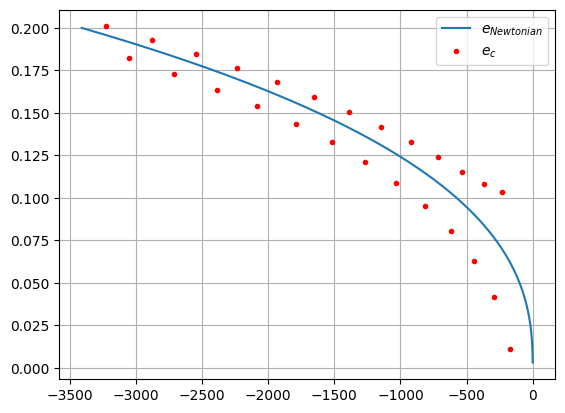

In [87]:
# Method 2: Dependent on knowing the orbital phase of the system; consistent but not as practical.
max_k = int(phi_ref[-1] // np.pi)
target_phi = np.arange(0, max_k) * np.pi
indices = np.searchsorted(phi_ref, target_phi)
indices = np.clip(indices, 0, len(phi_ref) - 1)
left_indices = np.maximum(0, indices - 1)
closer_mask = np.abs(phi_ref[left_indices] - target_phi) < np.abs(phi_ref[indices] - target_phi)
closest_indices = np.where(closer_mask, left_indices, indices)
fpn = fvalues[closest_indices]

fplus0 = fpn
fminus0 = np.roll(fpn, -1)

timec2 = timef[closest_indices]
e_c_3 = e_cmaker(fplus0, fminus0)
plt.plot(timef, e_newt, label=r"$e_{Newtonian}$")
plt.plot(timec2[1:-3], e_c_3[1:-3], 'r.', label=r"$e_c$")
plt.grid(True)
plt.legend()

[0.19604081 0.1920541  0.18764271 0.18358167 0.17902695 0.17488972
 0.17017206 0.16595853 0.16105293 0.15676552 0.15164039 0.14728729
 0.14190047 0.13750034 0.13179366 0.12738801 0.12128063 0.11695454
 0.11032594 0.10627591 0.09893505 0.09565569 0.08728566 0.08632683
 0.07636128 0.        ]


Text(0.5, 1.0, '$e=0.99$, no decay Newtonian orbit')

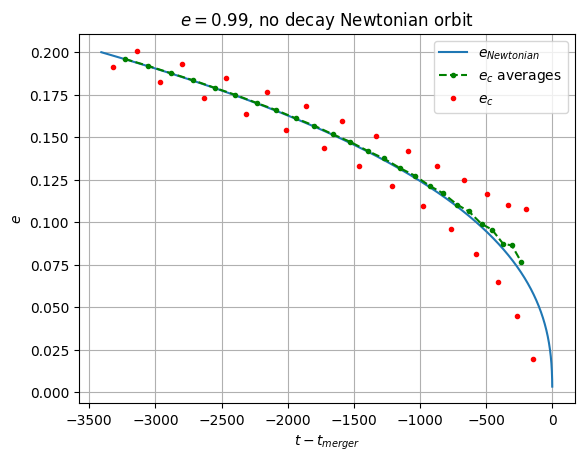

In [88]:
ec_top = e_c_array[1:-1:2]
ec_bot = e_c_array[2::2]
timec_top = timec[1:-1:2]
timec_bot = timec[2::2]
ec_topmod = np.roll(ec_top, 1)
timec_topmod = np.roll(timec_top, 1)
ec_a = np.average(np.array([ec_top, ec_bot]), axis =0)
time_a = np.average(np.array([timec_top, timec_bot]), axis =0)
ec_ave2 = np.average(np.array([ec_topmod, ec_bot]), axis=0)
time_ave2 = np.average(np.array([timec_topmod, timec_bot]), axis =0)
ec_ave = np.zeros(ec_a.size + ec_ave2.size, dtype = ec_a.dtype)
time_ave = np.zeros(time_a.size + time_ave2.size, dtype = time_a.dtype)
ec_ave[0::2] = ec_a
ec_ave[1:-1:2] = ec_ave2[1:]
time_ave[0::2] = time_a
time_ave[1:-1:2] = time_ave2[1:]
print(ec_ave)

# ec_ave = ec_a
# time_ave = time_a
plt.plot(timef, e_newt, label=r"$e_{Newtonian}$")
plt.plot(time_ave[:-1], ec_ave[:-1], 'g--.', label=r"$e_c$ averages")
plt.plot(timec[1:], e_c_array[1:], 'r.', label=r"$e_c$")
plt.xlabel(r'$t - t_{merger}$')
plt.ylabel(r'$e$')
# plt.xlim(-60000, -56000)
# plt.ylim(0.2, 0.5)
plt.grid(True)
plt.legend()
# plt.title('(2,2) Eccentricity with third body perturbation on orbital plane.\n'+ r'$q = 0.01$, $R_3 = 100M$, $m_3 = M$')
plt.title(r'$e=0.99$, no decay Newtonian orbit')
#plt.ylim(0.199995, 0.200005)

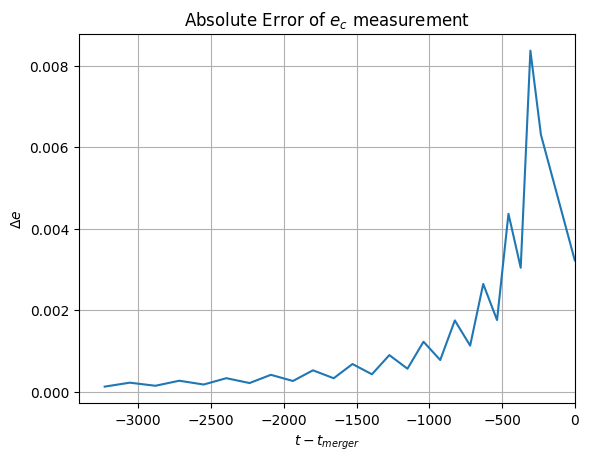

In [89]:
enewtcomp = np.interp(time_ave, timef, e_newt)
plt.plot(time_ave, np.abs(enewtcomp - ec_ave))
plt.xlim(np.min(timef), np.max(timef))
plt.title(r"Absolute Error of $e_c$ measurement")
plt.xlabel(r"$t-t_{merger}$")
plt.ylabel(r"$\Delta e$")
plt.grid(True)

In [90]:
# Define new function that fixes and streamlines everything
# I know there's ways of getting the phase (either np.phase for complex strains or np.arctan2 for separate hplus and hcross forms.),
# so I have to input the phase of the waveform.
# def ec22(fplus, fminus):
#     iksi = (abs(fplus - fminus))/(fplus + fminus)
#     psi = (1/3)*np.arctan2(np.sqrt(1-iksi**2), iksi)
#     e_c = np.cos(psi) - np.sqrt(3)*np.sin(psi)
#     return e_c

# def ec33(fplus, fminus):
#     iksi = (abs(fplus - fminus))/(fplus + fminus)
#     theta = (1/3)*np.arctan((1242*np.sqrt(3)/iksi)*(np.sqrt(35266176 - 31184003*iksi**2 - 3675129*iksi**4)/(15712542 + 1225043*iksi**2)))
#     return (1/138)*(-107*iksi + np.sqrt(54648 + 11449*iksi)*np.cos(theta)-np.sqrt(163944 + 34347*iksi)*np.sin(theta))

# def ec44func(e):
#     return (2*e*(6944-5700*e**2+261*e**4))/(8192-1513*e**2-3669*e**4)

# def eccraft(t0, h, isOverall):  #h is either in pure complex form, or ordered as [h22+, h22x, h33+, h33x, h44+, h44x], or [h22+, h22x]
#     if np.shape(np.shape(h))[0] == 1: theta = np.angle(h)
#     else: 
#         theta = []
#         for i in range(np.shape(h)[0]):
#             theta.append(np.arctan2(-h[2*i+1], h[2*i]))
#         theta = np.array(theta)
#     dt = t0[1] - t0[0]
#     dtheta_dt = sp.signal.savgol_filter(theta, window_length=15, polyorder=3, deriv=1, delta=dt)
#     fvalues = dtheta_dt / (2 * np.pi)
#     dfvalues = sp.signal.savgol_filter(fvalues, window_length=15, polyorder=3, deriv=1, delta=dt)
#     zero_crossings = np.where(dfvalues[1:] * dfvalues[:-1] < 0)[0]
#     zero_crossings2 = np.roll(zero_crossings, shift=1)
#     zero_crossings3 = np.average(np.array([zero_crossings, zero_crossings2]), axis=0).astype(int)
#     fplus = fvalues[zero_crossings]
#     fminus = fvalues[zero_crossings2]
#     iksi = (abs(fplus - fminus))/(fplus + fminus)
#     if isOverall:
#         e_c_array = ec22(fplus, fminus)
#     else:
#         E_flux = sp.signal.savgol_filter(abs(h), window_length=15, polyorder=3, deriv=1, delta=dt)**2
#         e_c22 = ec22(fplus, fminus)
#         e_c33 = ec33(fplus, fminus)
#         def ec44(e):
#             return ec44func(e) - iksi
#         e_c44 = sp.optimize.root_scalar(ec44, bracket=[0,1], method="brentq")
#         e_c_array = 
        
#     timec = t0[zero_crossings3]
#     ec_top = e_c_array[1:-1:2]
#     ec_bot = e_c_array[2::2]
#     timec_top = timec[1:-1:2]
#     timec_bot = timec[2::2]
#     ec_ave = np.average(np.array([ec_top, ec_bot]), axis =0)
#     time_ave = np.average(np.array([timec_top, timec_bot]), axis =0)
#     return time_ave, ec_ave

# htest = [-hcross(a_ref, e_newt, phi_ref, d, q, M), hplus(a_ref, e_newt, phi_ref, d, q, M)]
# a, b = eccraft(timef, htest, True)
# plt.plot(a, b, 'r-.')
# plt.plot(timef, e_newt)